In [1]:
from torch import nn
import torch
import math
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch import Tensor

from src.Dataset import dataset_TES
from src.ParametricTSNE import train_ptsne, plot_results
from src.GaussianMixture import gaussian_mixture

In [2]:
weights = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]

data_train, data_test, expected_prob = dataset_TES(weights = weights,
                                                path_test = r'C:\Users\dalbe\Documents\Backup datasets\TES\NIST test/',
                                                path_train = r'C:\Users\dalbe\Documents\Backup datasets\TES\NIST train/',
                                                signal_size = 8192,
                                                interval = [0,350],
                                                order_dB = False,
                                                plot_expected = True,
                                                n_photon_number = 50)

In [ ]:
params = {
        'network' : {
            'dim_input' : 350,
            'dim_emb' : 1
            },
        'data' : {
            'weights' : weights
            },
        'tSNE' : {
            'perplexity' : 100,
            'early_exaggeration' : 4,
            'early_exaggeration_constant' : 12,
            'dist_func_name' : 'euc',
            'bin_search_tol' : 1e-5,
            'bin_search_max_iter' : 300,
            'min_allowed_sig_sq' : 0,
            'max_allowed_sig_sq' : 1000,
            },
        'training' : {
            'n_epochs' : 100,
            'learning_rate' : 0.002,
            'alpha_loss' : 1,
            'batch_size' : 1000,
            'n_cluster' : 35
            }
        }

In [ ]:
def weights_init(m: nn.Module) -> None:
    if isinstance(m, (nn.Linear,)):
        nn.init.kaiming_normal_(m.weight.data)
        m.bias.data.fill_(0.01)
    elif isinstance(m, (nn.BatchNorm1d,)):
        m.weight.data.fill_(1.0)
        m.bias.data.fill_(0)

In [ ]:
def size_conv(L_in,
              padding : int = 0,
              dilation : int = 1,
              kernel_size : int = 5,
              stride : int = 2):

    return (((L_in + 2*padding - dilation*(kernel_size - 1)) - 1) / stride) + 1

def size_deconv(L_in,
                padding : int = 0,
                dilation : int = 1,
                kernel_size : int = 5,
                stride : int = 2,
                output_padding : int = 0):
    
    return (L_in - 1)*stride - 2*padding + dilation*(kernel_size - 1) + output_padding + 1

In [ ]:
class Network1(nn.Module):

    def __init__(self, dim_input, dim_emb=2):
        super().__init__()

        size_conv1 = size_conv(dim_input, 
                                padding = 0,
                                kernel_size = 4,
                                stride = 2)
        size_conv2 = size_conv(size_conv1,
                                padding = 0,
                                kernel_size = 4,
                                stride = 2)
        size_conv3 = size_conv(size_conv2,
                                padding = 0,
                                kernel_size = 4,
                                stride = 2)

        size_deconv1 = size_deconv(size_conv3,
                                    padding = 0,
                                    kernel_size = 4,
                                    stride = 2,
                                    output_padding = 0)
        size_deconv2 = size_deconv(size_deconv1,
                                    padding = 0,
                                    kernel_size = 4,
                                    stride = 2,
                                    output_padding = 0)
        size_deconv3 = size_deconv(size_deconv2,
                                    padding = 0,
                                    kernel_size = 4,
                                    stride = 2,
                                    output_padding = 0)

        print(size_conv1, size_conv2, size_conv3)
        print(size_deconv1, size_deconv2, size_deconv3)

        self.dim_input = dim_input
        self.dim_emb = dim_emb
        
        self.encoder1 = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size = 4, stride = 2, padding = 0),
            nn.BatchNorm1d(8),
            nn.ReLU(True),
            nn.Conv1d(8, 16, kernel_size = 4, stride = 2, padding = 0),
            nn.BatchNorm1d(16),
            nn.ReLU(True),
            nn.Conv1d(16, 16, kernel_size = 4, stride = 2, padding = 0),
            nn.ReLU(True),

            nn.Flatten(start_dim=1),
        )

        self.encoder2 = nn.Sequential(
            nn.Linear(int(16*size_conv3), 128),
            nn.ReLU(True),
            nn.Linear(128, dim_emb),
        )


        self.decoder1 = nn.Sequential(
            nn.Linear(dim_emb, 128),
            nn.ReLU(True),
            nn.Linear(128, int(16*size_conv3)),
            nn.ReLU(True)
        )

        self.decoder2 = nn.Sequential(

            nn.Unflatten(dim=1, unflattened_size=(16, int(size_conv3))),

            nn.ConvTranspose1d(16, 16, kernel_size = 4, stride = 2, padding = 0, output_padding = 0),
            nn.BatchNorm1d(16),
            nn.ReLU(True),
            nn.ConvTranspose1d(16, 8, kernel_size = 4, stride = 2, padding = 0, output_padding = 0),
            nn.BatchNorm1d(8),
            nn.ReLU(True),
            nn.ConvTranspose1d(8, 1, kernel_size = 4, stride = 2, padding = 0, output_padding = 0)
        )

        self.apply(weights_init)

    def forward(self, x, 
                encode = False, 
                decode = False,
                both = False):
        x = x.view(-1,1,self.dim_input)
        if encode:
            x = self.encoder1(x)
            return self.encoder2(x).view(-1,self.dim_emb)
        elif both:
            x = self.encoder1(x)
            encoder_ = self.encoder2(x)
            decoder_ = self.decoder1(encoder_)
            decoder_ = self.decoder2(decoder_)
            return encoder_.view(-1,self.dim_emb), decoder_.view(-1,self.dim_input)
        elif decode:
            x = self.decoder1(x)
            return self.decoder2(x).view(-1,self.dim_input)

In [ ]:
model = Network1(**params['network'])

174.0 86.0 42.0
86.0 174.0 350.0


In [ ]:
train_ptsne(X_high = data_train[:30_000],
            # Model
            model = model,
            # Params
            params = params,
            # Training
            **params['training'],
            # Files
            model_name = '3',
            dev = 'cpu',
            save_dir_path = 'src/Models',
            # t-SNE
            **params['tSNE'],
            # Display load
            verbose = True)

100%|██████████| 10/10 [00:50<00:00,  5.08s/it]

Model saved as src/Models -> 3


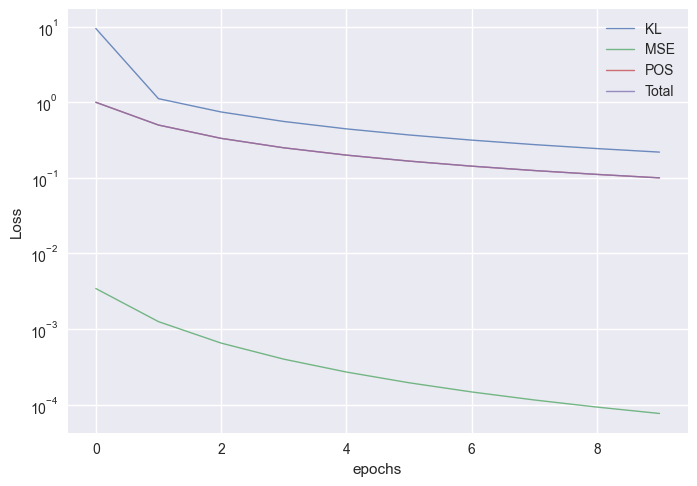

network
   dim_input : 350
   dim_emb : 1
data
   weights : [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]
tSNE
   perplexity : 100
   early_exaggeration : 4
   early_exaggeration_constant : 12
   dist_func_name : euc
   bin_search_tol : 1e-05
   bin_search_max_iter : 300
   min_allowed_sig_sq : 0
   max_allowed_sig_sq : 1000
training
   n_epochs : 10
   learning_rate : 0.002
   alpha_loss : 1
   batch_size : 1000
   n_cluster : 35


In [ ]:
plot_results(model,
             folder_name = 'src/Models',
             model_name = '3')

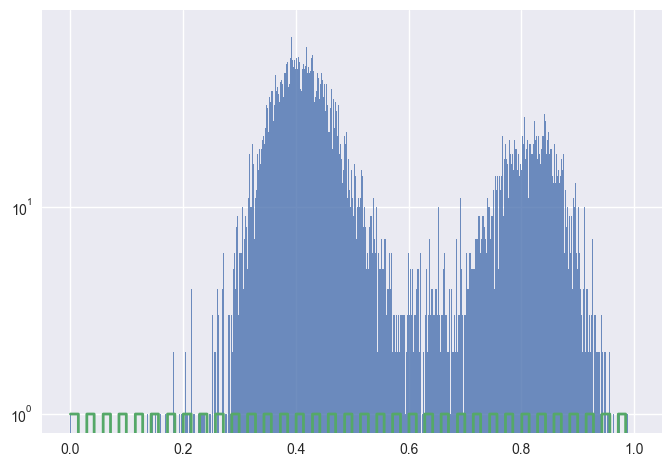

array([[0.6757235 ],
       [0.79071474],
       [0.38821617],
       ...,
       [0.47020674],
       [0.90380913],
       [0.3914062 ]], dtype=float32)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

folder_name = 'src/Models'
model_name = '3'
n_cluster = 35
X_ = np.linspace(0,1,1000)

train_dl = torch.from_numpy(data_test).view(-1, 350).float()
train_dl = (train_dl - train_dl.min()) / (train_dl.max() - train_dl.min())

model.load_state_dict(torch.load(f'{folder_name}/model {model_name}.pt'))
model.eval()

emb = model(train_dl, encode=True).detach().numpy()
emb = (emb - emb.min()) / (emb.max() - emb.min())

with plt.style.context("seaborn-v0_8"):
        
    plt.hist(emb, alpha=0.8, bins=3000)
    plt.plot(X_, signal.square(2 * np.pi * n_cluster * X_), linewidth=2)
    plt.yscale('log')
    plt.show()

emb

In [ ]:
name_method = 'AUTO'
gm = gaussian_mixture(emb,
                      data_test,
                      number_cluster = 24,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = means,#get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.01,
                plot_gaussians=True)

NameError: name 'means' is not defined

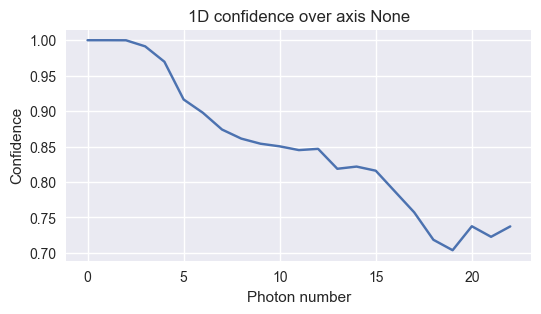

In [ ]:
gm.plot_confidence_1d(expected_prob=expected_prob)